In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler


def make_direction_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    for d in [5, 10, 20]:
        ma_col = f"MA{d}"
        ma_next = df[ma_col].shift(-1)
        dir_col = f"MA{d}_dir"
        df[dir_col] = np.where(ma_next > df[ma_col], 1, -1)

    df = df.iloc[:-1].reset_index(drop=True)
    return df



def load_no_macro():
    data_dir = Path("data/features/only features")
    files = list(data_dir.glob("*.csv"))

    stock_data = {}
    for f in files:
        key = f.stem.replace("_features", "")
        stock_data[key] = pd.read_csv(f)

    labeled = {}
    for ticker, df in stock_data.items():
        labeled[ticker] = make_direction_labels(df)


    return labeled



def load_macro():
    data_dir = Path("data/features/features_with_ME")
    files = list(data_dir.glob("*.csv"))

    stock_data = {}
    for f in files:
        name = f.stem
        name = name.replace("_features_ME", "")
        stock_data[name] = pd.read_csv(f)

    labeled = {}
    for ticker in stock_data:
        labeled[ticker] = make_direction_labels(stock_data[ticker])

    
    return labeled


In [19]:
targets_dir = ["MA5_dir", "MA10_dir", "MA20_dir"]

ME_cols = ["FFR_Level", "CPI_YoY", "UNRATE_Level", "YC_Slope_10Y3M", "PMI_Level"]
ME_weight = 50.0

data_no_macro = load_no_macro()
data_macro = load_macro()

split_data_no_macro = {}
split_data_macro = {}

for ticker, df in data_no_macro.items():

    df = df.copy().sort_values("Date")
    exclude_cols = ["Date"] + targets_dir
    
    split_idx = int(len(df) * 0.8)

    X_all = df.drop(columns=exclude_cols, errors="ignore")
    X_train_raw = X_all.iloc[:split_idx].copy()
    X_test_raw  = X_all.iloc[split_idx:].copy()

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train_raw),
                           columns=X_train_raw.columns, index=X_train_raw.index)
    X_test = pd.DataFrame(scaler.transform(X_test_raw),
                          columns=X_test_raw.columns, index=X_test_raw.index)

    split_data_no_macro[ticker] = {
        "X_train": X_train,
        "X_test": X_test
    }

    for t in targets_dir:
        y_all = df[t]
        split_data_no_macro[ticker][t] = {
            "y_train": y_all.iloc[:split_idx],
            "y_test":  y_all.iloc[split_idx:]
        }

for ticker, df in data_macro.items():

    df = df.copy().sort_values("Date")
    exclude_cols = ["Date"] + targets_dir
    
    split_idx = int(len(df) * 0.8)

    X_all = df.drop(columns=exclude_cols, errors="ignore")
    X_train_raw = X_all.iloc[:split_idx].copy()
    X_test_raw  = X_all.iloc[split_idx:].copy()

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train_raw),
                           columns=X_train_raw.columns, index=X_train_raw.index)
    X_test = pd.DataFrame(scaler.transform(X_test_raw),
                          columns=X_test_raw.columns, index=X_test_raw.index)

    for col in ME_cols:
        if col in X_train.columns:
            X_train[col] *= ME_weight
            X_test[col]  *= ME_weight

    split_data_macro[ticker] = {
        "X_train": X_train,
        "X_test": X_test
    }

    for t in targets_dir:
        y_all = df[t]
        split_data_macro[ticker][t] = {
            "y_train": y_all.iloc[:split_idx],
            "y_test":  y_all.iloc[split_idx:]
        }



In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, AdaBoostRegressor
from catboost import CatBoostRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


def run_all_models(split_data):

    targets_dir = ["MA5_dir", "MA10_dir", "MA20_dir"]

    model_configs = {

        "DecisionTree": lambda: DecisionTreeRegressor(
            random_state=42, max_depth=None, min_samples_leaf=5
        ),

        "SVM": lambda: SVR(kernel="linear", C=1.0, epsilon=0.1),

        "Bagging": lambda: BaggingRegressor(
            estimator=DecisionTreeRegressor(min_samples_leaf=5, random_state=42),
            n_estimators=300, bootstrap=True, n_jobs=-1, random_state=42
        ),

        "RandomForest": lambda: RandomForestRegressor(
            n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1
        ),

        "AdaBoost": lambda: AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
            n_estimators=300, learning_rate=0.1, random_state=42
        ),

        "CatBoost": lambda: CatBoostRegressor(
            iterations=300, depth=6, learning_rate=0.1,
            loss_function="RMSE", random_seed=42,
            verbose=False, allow_writing_files=False
        ),

        "XGBoost": lambda: XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective="binary:logistic", random_state=42
        ),

        "LightGBM": lambda: LGBMClassifier(
            n_estimators=400, learning_rate=0.03,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1
        )
    }


    results = []
    saved_models = { ticker:{} for ticker in split_data.keys() }

    for ticker, parts in split_data.items():

        X_train = parts["X_train"]
        X_test  = parts["X_test"]

        for model_name, model_fn in model_configs.items():

            saved_models[ticker][model_name] = {}

            for target in targets_dir:

                y_train = parts[target]["y_train"]
                y_test  = parts[target]["y_test"]

                model = model_fn()

                if model_name in ["XGBoost", "LightGBM"]:
                    y_train_bin = (y_train == 1).astype(int)
                    y_test_bin  = (y_test == 1).astype(int)
                    model.fit(X_train, y_train_bin)
                    pred_bin = model.predict(X_test)
                    y_pred = np.where(pred_bin == 1, 1, -1)
                else:
                    model.fit(X_train, y_train)
                    pred_cont = model.predict(X_test)
                    y_pred = np.where(pred_cont > 0, 1, -1)

                mae  = mean_absolute_error(y_test, y_pred)
                mse  = mean_squared_error(y_test, y_pred)
                rmse = np.sqrt(mse)
                r2   = r2_score(y_test, y_pred)

                results.append({
                    "Ticker": ticker,
                    "Target": target.replace("_dir", ""),
                    "Model": model_name,
                    "MAE": mae,
                    "MSE": mse,
                    "RMSE": rmse,
                    "R2": r2
                })

                saved_models[ticker][model_name][target] = model

    df_results = pd.DataFrame(results)
    return df_results, saved_models


In [7]:
results_no_macro, models_no_macro = run_all_models(split_data_no_macro)
results_macro,    models_macro    = run_all_models(split_data_macro)


In [21]:
comparison = results_no_macro.merge(
    results_macro,
    on=["Ticker", "Target", "Model"],
    suffixes=("_noME", "_ME")
)

comparison["MAE_diff"]  = comparison["MAE_ME"]  - comparison["MAE_noME"]
comparison["RMSE_diff"] = comparison["RMSE_ME"] - comparison["RMSE_noME"]
comparison["R2_diff"]   = comparison["R2_ME"]   - comparison["R2_noME"]

comparison


,Ticker,Target,Model,MAE_noME,MSE_noME,RMSE_noME,R2_noME,MAE_ME,MSE_ME,RMSE_ME,R2_ME,MAE_diff,RMSE_diff,R2_diff
0,AAPL,MA5,DecisionTree,0.535211,1.070423,1.034612,-0.079470,0.514085,1.028169,1.013987,-0.036859,-0.021127,-0.020626,0.042611
1,AAPL,MA10,DecisionTree,0.366197,0.732394,0.855800,0.258188,0.373239,0.746479,0.863990,0.243922,0.007042,0.008190,-0.014266
2,AAPL,MA20,DecisionTree,0.295775,0.591549,0.769122,0.387931,0.295775,0.591549,0.769122,0.387931,0.000000,0.000000,0.000000
3,AAPL,MA5,SVM,0.345070,0.690141,0.830747,0.304026,0.338028,0.676056,0.822226,0.318230,-0.007042,-0.008521,0.014204
4,AAPL,MA10,SVM,0.281690,0.563380,0.750587,0.429375,0.274648,0.549296,0.741145,0.443641,-0.007042,-0.009442,0.014266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,ORCL,MA10,XGBoost,0.218310,0.436620,0.660772,0.548235,0.204225,0.408451,0.639101,0.577381,-0.014085,-0.021671,0.029146
188,ORCL,MA20,XGBoost,0.140845,0.281690,0.530745,0.697792,0.133803,0.267606,0.517306,0.712902,-0.007042,-0.013439,0.015110
189,ORCL,MA5,LightGBM,0.345070,0.690141,0.830747,0.297278,0.387324,0.774648,0.880141,0.211231,0.042254,0.049394,-0.086048
190,ORCL,MA10,LightGBM,0.211268,0.422535,0.650027,0.562808,0.211268,0.422535,0.650027,0.562808,0.000000,0.000000,0.000000


In [ ]:
summary_noME = (
    results_no_macro
    .groupby(["Ticker", "Model"])
    .agg({
        "MAE": "mean",
        "MSE": "mean",
        "RMSE": "mean",
        "R2": "mean"
    })
    .reset_index()
)

summary_noME.columns = ["Ticker", "Model", "MAE_avg", "MSE_avg", "RMSE_avg", "R2_avg"]


summary_ME = (
    results_macro
    .groupby(["Ticker", "Model"])
    .agg({
        "MAE": "mean",
        "MSE": "mean",
        "RMSE": "mean",
        "R2": "mean"
    })
    .reset_index()
)

summary_ME.columns = ["Ticker", "Model", "MAE_avg", "MSE_avg", "RMSE_avg", "R2_avg"]



summary_noME, summary_ME


(   Ticker         Model   MAE_avg   MSE_avg  RMSE_avg    R2_avg
 0    AAPL      AdaBoost  0.274648  0.549296  0.738422  0.441497
 1    AAPL       Bagging  0.281690  0.563380  0.746235  0.427356
 2    AAPL      CatBoost  0.293427  0.586854  0.764218  0.402842
 3    AAPL  DecisionTree  0.399061  0.798122  0.886512  0.188883
 4    AAPL      LightGBM  0.300469  0.600939  0.772401  0.388741
 ..    ...           ...       ...       ...       ...       ...
 59   ORCL  DecisionTree  0.401408  0.802817  0.888514  0.166406
 60   ORCL      LightGBM  0.237089  0.474178  0.679141  0.509219
 61   ORCL  RandomForest  0.253521  0.507042  0.694474  0.476167
 62   ORCL           SVM  0.347418  0.694836  0.832516  0.276356
 63   ORCL       XGBoost  0.237089  0.474178  0.676899  0.509655
 
 [64 rows x 6 columns],
    Ticker         Model   MAE_avg   MSE_avg  RMSE_avg    R2_avg
 0    AAPL      AdaBoost  0.276995  0.553991  0.743034  0.436393
 1    AAPL       Bagging  0.265258  0.530516  0.725611  0.460539

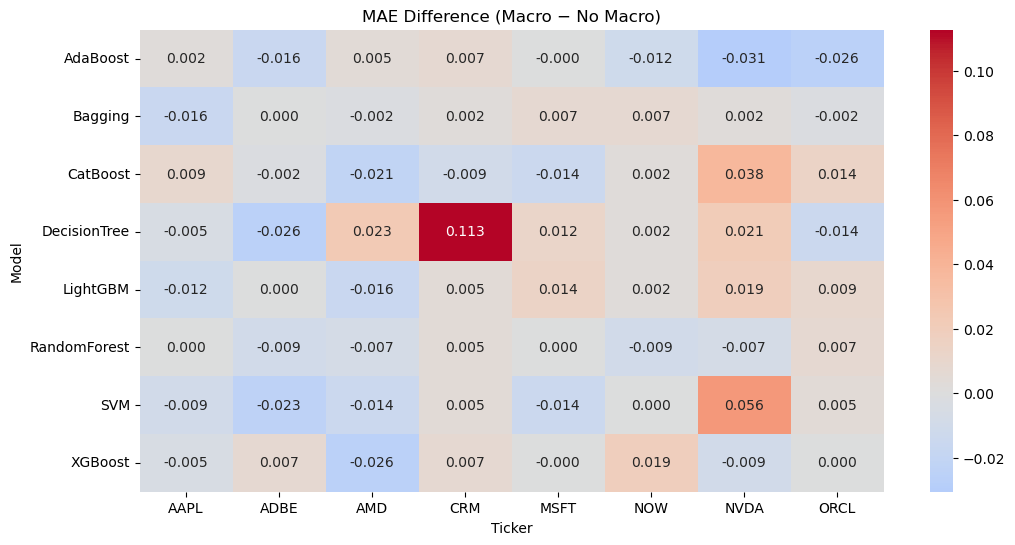

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

diff_MAE = summary_ME.merge(
    summary_noME,
    on=["Ticker", "Model"],
    suffixes=("_ME", "_noME")
)

diff_MAE["MAE_diff"] = diff_MAE["MAE_avg_ME"] - diff_MAE["MAE_avg_noME"]

pivot = diff_MAE.pivot(index="Model", columns="Ticker", values="MAE_diff")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("MAE Difference (Macro − No Macro)")
plt.show()
